# Notebook – Faysal
## Project: Voorspelling Jeugdpopulatie Almere (CBS Wijken & Buurten)

**Doel van dit notebook (fase 1):**  
Controleren of de opgeschoonde dataset (df_v6_clean) inhoudelijk en technisch geschikt is voor analyse en modellering.

Binnen fase 1 controleer ik:
- Structuur en datatypes (Describe Data)
- Missende waarden en duplicaten (Verify Data Quality)
- Onlogische waarden (bijv. negatieve aantallen, jeugd > totaal inwoners)
- Indeling per jaar (extra aandacht: wijkindeling wijzigt vanaf 2022)
- Afleiden van eenvoudige ratio-variabelen (% jeugd t.o.v. totaal)
- Opslaan van een analyse-klare dataset voor de volgende fases

In [1]:
import pandas as pd
from pathlib import Path

path = Path("../../data/processed/df_v6_clean_final.csv")

df = pd.read_csv(path)
df.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar
0,2018-01-01,WK003401,22790,3975,2420,2018
1,2019-01-01,WK003401,22875,3945,2415,2019
2,2020-01-01,WK003401,23275,4005,2485,2020
3,2021-01-01,WK003401,23530,4180,2465,2021
4,2022-01-01,WK003401,1635,175,150,2022


Ik laad de opgeschoonde dataset in vanuit data/processed. Met de check voorkom ik onduidelijke errors als het bestand of pad niet klopt.

In [2]:
df.shape, df.columns

((237, 6),
 Index(['Peildatum', 'Wijk', 'AantalInwoners_5', 'k_0Tot15Jaar_8',
        'k_15Tot25Jaar_9', 'Jaar'],
       dtype='str'))

Dit geeft het aantal rijen/kolommen en laat zien welke variabelen beschikbaar zijn voor het project.

In [3]:
df.info()
df.describe(include="all")
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Peildatum         237 non-null    str  
 1   Wijk              237 non-null    str  
 2   AantalInwoners_5  237 non-null    int64
 3   k_0Tot15Jaar_8    237 non-null    int64
 4   k_15Tot25Jaar_9   237 non-null    int64
 5   Jaar              237 non-null    int64
dtypes: int64(4), str(2)
memory usage: 11.2 KB


Peildatum           0
Wijk                0
AantalInwoners_5    0
k_0Tot15Jaar_8      0
k_15Tot25Jaar_9     0
Jaar                0
dtype: int64

df.info() controleert datatypes en of kolommen gevuld zijn.

df.describe() geeft basisstatistiek (min/max/mean) om uitschieters te herkennen.

isnull().sum() laat zien of er missende waarden zijn (belangrijk voor modelleren).
Dit past bij “Describe & Verify Data Quality” uit de Data Understanding-fase.

In [4]:
df.duplicated().sum()

np.int64(0)

Dubbele rijen kunnen tellingen vertekenen, dus ik controleer of records dubbel voorkomen. 

In [5]:
df["Peildatum"] = pd.to_datetime(df["Peildatum"], errors="coerce")
df["Jaar"] = df["Peildatum"].dt.year

df[["Peildatum", "Jaar"]].head()

,Peildatum,Jaar
0,2018-01-01,2018
1,2019-01-01,2019
2,2020-01-01,2020
3,2021-01-01,2021
4,2022-01-01,2022


Ik zet Peildatum om naar datetime en leid Jaar af. Dit maakt groeperen per jaar mogelijk en voorkomt errors bij groupby("Jaar"). 

In [6]:
kol_totaal = "AantalInwoners_5"
kol_0_15 = "k_0Tot15Jaar_8"
kol_15_25 = "k_15Tot25Jaar_9"

checks = {
    "negatief_0_15": (df[kol_0_15] < 0).sum(),
    "negatief_15_25": (df[kol_15_25] < 0).sum(),
    "negatief_totaal": (df[kol_totaal] < 0).sum(),
    "0_15_groter_dan_totaal": (df[kol_0_15] > df[kol_totaal]).sum(),
    "15_25_groter_dan_totaal": (df[kol_15_25] > df[kol_totaal]).sum(),
}

checks

{'negatief_0_15': np.int64(0),
 'negatief_15_25': np.int64(0),
 'negatief_totaal': np.int64(0),
 '0_15_groter_dan_totaal': np.int64(0),
 '15_25_groter_dan_totaal': np.int64(0)}

Aantallen inwoners en aantallen jongeren horen niet negatief te zijn. Ook kan een leeftijdsgroep niet groter zijn dan het totaal aantal inwoners in dezelfde wijk/peildatum. Dit is een eenvoudige inhoudelijke kwaliteitscontrole. 

In [7]:
df.groupby("Jaar")["Wijk"].nunique().sort_index()

Jaar
2018     5
2019     5
2020     5
2021     5
2022    53
2023    54
2024    55
2025    55
Name: Wijk, dtype: int64

Ik controleer hoeveel unieke wijken per jaar aanwezig zijn. Als dit rond 2022 verandert, kan dat invloed hebben op trendvergelijking en op hoe we het model opzetten. 

In [8]:
df["pct_0_15"] = (df[kol_0_15] / df[kol_totaal]) * 100
df["pct_15_25"] = (df[kol_15_25] / df[kol_totaal]) * 100

df[["Wijk", "Jaar", kol_totaal, kol_0_15, kol_15_25, "pct_0_15", "pct_15_25"]].head()

,Wijk,Jaar,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,pct_0_15,pct_15_25
0,WK003401,2018,22790,3975,2420,17.441860,10.618692
1,WK003401,2019,22875,3945,2415,17.245902,10.557377
2,WK003401,2020,23275,4005,2485,17.207304,10.676692
3,WK003401,2021,23530,4180,2465,17.764556,10.475988
4,WK003401,2022,1635,175,150,10.703364,9.174312


Naast absolute aantallen is het percentage jeugd per wijk nuttig, omdat wijken in totaal aantal inwoners verschillen. Dit is een eenvoudige afgeleide variabele (feature) voor latere analyse/modellering. 

In [9]:
df[["pct_0_15", "pct_15_25"]].describe()

,pct_0_15,pct_15_25
count,237.000000,237.000000
mean,18.277507,12.805460
std,6.034239,6.198061
min,2.083333,6.250000
25%,15.671642,10.135135
50%,17.287234,11.790393
75%,19.288646,14.258735
max,57.142857,83.333333


Hier kijk ik of percentages logisch zijn (bijv. geen negatieve waarden en geen extreem hoge waarden boven 100).

In [10]:
output_path = Path("../../data/processed/df_v8_ready_for_analysis.csv")
df.to_csv(output_path, index=False)

output_path.as_posix()

'../../data/processed/df_v8_ready_for_analysis.csv'

Ik sla een “analyse-klare” versie op, zodat we in de volgende fases (analyse/modellering) allemaal dezelfde kolommen en datatypes gebruiken.

---
# Fase 2 – Data Understanding


**Doel:** Inzicht krijgen in relaties en patronen tussen jeugdpopulatie en totale bevolking per wijk.

In deze fase wordt onderzocht hoe de jeugdpopulatie (0–15 en 15–25 jaar) zich verhoudt tot de totale bevolking binnen de wijken van Almere. Waar in eerdere analyses de nadruk lag op ontwikkeling door de tijd per wijk, richt deze analyse zich op onderlinge samenhang en structurele verschillen tussen wijken.

De centrale vragen zijn:

- Is er een verband tussen het totaal aantal inwoners en het aantal jongeren?
- Verschillen wijken structureel in het aandeel jeugd?
- Is er een duidelijke samenhang tussen de leeftijdsgroepen 0–15 en 15–25?
- Is er een opvallende verandering zichtbaar rond 2022?

Door deze patronen te analyseren ontstaat een beter begrip van de demografische structuur van Almere. Dit vormt een inhoudelijke basis voor latere modelkeuzes.


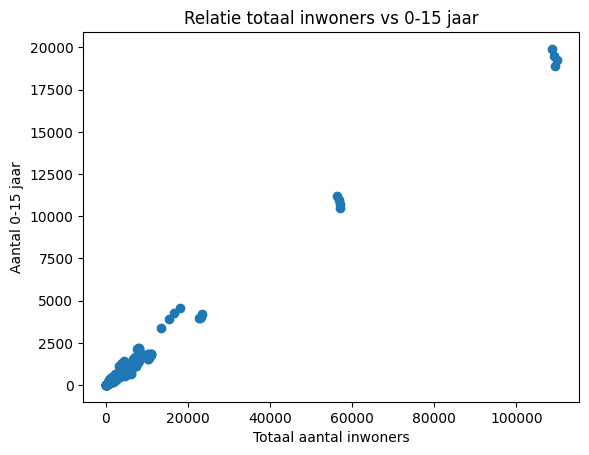

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df["AantalInwoners_5"], df["k_0Tot15Jaar_8"])
plt.xlabel("Totaal aantal inwoners")
plt.ylabel("Aantal 0-15 jaar")
plt.title("Relatie totaal inwoners vs 0-15 jaar")
plt.show()

Deze grafiek laat zien of grotere wijken automatisch meer jongeren hebben.
Een duidelijk stijgend patroon wijst op een positieve samenhang.

In [12]:
df[["AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9"]].corr()

,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9
AantalInwoners_5,1.000000,0.995671,0.996897
k_0Tot15Jaar_8,0.995671,1.000000,0.989825
k_15Tot25Jaar_9,0.996897,0.989825,1.000000


De correlatiematrix toont de sterkte van samenhang tussen populatie en jeugdgroepen.
Een hoge correlatie betekent dat variabelen sterk samen bewegen.

In [13]:
df.groupby("Wijk")["pct_0_15"].mean().sort_values(ascending=False)

Wijk
WK003460      37.611618
WK003476      32.728747
WK003465      31.482948
WK003411      30.235383
WK003463      27.546223
WK003431      24.374011
WK003462      24.131289
WK003452      22.132781
WK003466      22.056089
WK003456      21.969697
WK003477      21.368218
WK003404      21.104130
WK003461      19.926085
WK003425      19.455410
WK003405      19.249612
WK003408      18.970890
WK003444      18.763897
WK003435      18.703704
WK003403      18.499525
WK003450      18.351393
WK003442      18.309659
WK003406      18.196129
WK003451      17.960233
WK003430      17.796249
WK003443      17.671747
WK003402      17.379672
WK003426      17.367668
WK003449      17.366436
WK003427      17.347492
WK003424      17.205024
WK003445      17.135856
WK003419      17.108428
WK003446      16.900533
WK003409      16.824758
WK003407      16.543892
WK003448      16.473234
WK003428      16.411152
WK003423      16.354708
WK003447      15.888566
WK003437      15.752688
WK003422      15.634217
WK003453   

Hier wordt gekeken welke wijken gemiddeld een hoger percentage jeugd hebben.
Dit geeft inzicht in structurele demografische verschillen tussen wijken.

In [14]:
df.groupby("Jaar")["pct_0_15"].mean()

Jaar
2018    19.652178
2019    20.126244
2020    20.387175
2021    20.466394
2022    19.103347
2023    18.254221
2024    17.566630
2025    17.531624
Name: pct_0_15, dtype: float64

Deze analyse controleert of er een duidelijke breuk zichtbaar is rond 2022.
Een plotselinge afwijking kan samenhangen met wijziging in wijkindeling.

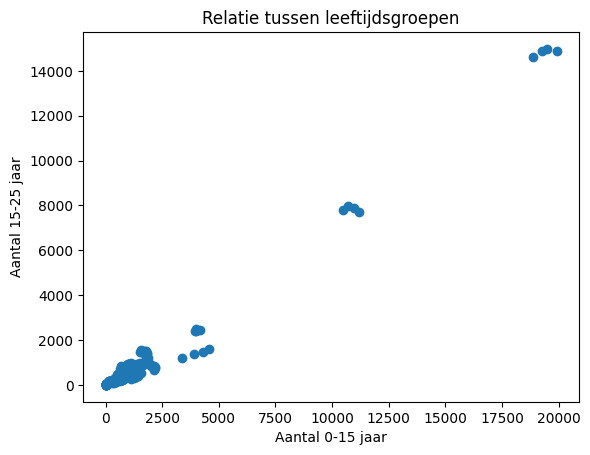

In [15]:
plt.scatter(df["k_0Tot15Jaar_8"], df["k_15Tot25Jaar_9"])
plt.xlabel("Aantal 0-15 jaar")
plt.ylabel("Aantal 15-25 jaar")
plt.title("Relatie tussen leeftijdsgroepen")
plt.show()

Deze grafiek laat zien of wijken met veel jonge kinderen ook veel jongeren hebben.
Een sterke samenhang wijst op een consistente leeftijdsstructuur binnen wijken.

---
# Fase 3 – Data Preparation


**Doel:** In deze fase worden de feature-datasets van het team samengevoegd tot één modelklare dataset.
De merge gebeurt op de sleutel:

Wijk
Jaar

De uiteindelijke output van deze fase is:

../../data/processed/df_v12_model_ready.csv

In [34]:
import pandas as pd
from pathlib import Path

base_path = Path("../../data/processed/df_v8_ready_for_analysis.csv")

df_base = pd.read_csv(base_path)

df_base.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312


De basisdataset bevat de opgeschoonde demografische data per wijk en jaar.
Deze dataset vormt het uitgangspunt waarop alle nieuwe features worden gekoppeld.

In [35]:
df_base[["Wijk","Jaar"]].head()

df_base.duplicated(subset=["Wijk","Jaar"]).sum()

np.int64(0)

Voor het samenvoegen van datasets moet elke combinatie van Wijk en Jaar uniek zijn.
Duplicaten zouden leiden tot foutieve merges en dubbele rijen.

In [36]:
ratio_path = Path("../../data/processed/df_v10_ratio_temp.csv")

df_ratio = pd.read_csv(ratio_path)

df_ratio.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,0.177646,0.104760
4,2018-01-01,WK003402,108800,19915,14890,2018,18.304228,13.685662,0.183042,0.136857


In [37]:
df_ratio = df_ratio[["Wijk","Jaar","Ratio_0_15","Ratio_15_25"]]

Deze dataset bevat de verhouding tussen jongeren en totale bevolking.
Deze variabelen worden later gebruikt als mogelijke predictor voor de jeugdpopulatie.

In [38]:
df_merged = df_base.merge(
    df_ratio,
    on=["Wijk","Jaar"],
    how="left"
)

df_merged.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,NaN,NaN
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,NaN,NaN
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,NaN,NaN
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,NaN,NaN
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312,NaN,NaN


Een left join wordt gebruikt zodat alle rijen uit de basisdataset behouden blijven.

Als bepaalde features ontbreken (bijvoorbeeld door filtering van jaren), verschijnen deze als NaN.

In [39]:
print("Rows base:", len(df_base))
print("Rows merged:", len(df_merged))

df_merged.isnull().sum()

Rows base: 237
Rows merged: 237


Peildatum             0
Wijk                  0
AantalInwoners_5      0
k_0Tot15Jaar_8        0
k_15Tot25Jaar_9       0
Jaar                  0
pct_0_15              0
pct_15_25             0
Ratio_0_15          237
Ratio_15_25         237
dtype: int64

Na de merge moet het aantal rijen gelijk blijven.

Daarnaast controleren we of er ontbrekende waarden zijn ontstaan.

In [40]:
model_cols = [
"Wijk",
"Jaar",
"AantalInwoners_5",
"k_0Tot15Jaar_8",
"k_15Tot25Jaar_9",
"Ratio_0_15",
"Ratio_15_25"
]

df_model = df_merged[model_cols].copy()

df_model.head()

,Wijk,Jaar,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Ratio_0_15,Ratio_15_25
0,WK003401,2018,22790,3975,2420,NaN,NaN
1,WK003401,2019,22875,3945,2415,NaN,NaN
2,WK003401,2020,23275,4005,2485,NaN,NaN
3,WK003401,2021,23530,4180,2465,NaN,NaN
4,WK003401,2022,1635,175,150,NaN,NaN


Alleen variabelen die relevant zijn voor het model worden geselecteerd.

In [41]:
df_model.dtypes

Wijk                    str
Jaar                  int64
AantalInwoners_5      int64
k_0Tot15Jaar_8        int64
k_15Tot25Jaar_9       int64
Ratio_0_15          float64
Ratio_15_25         float64
dtype: object

Machine-learning modellen werken alleen met numerieke inputvariabelen.

Daarom controleren we of alle modelvariabelen numeriek zijn.

In [42]:
output_path = Path("../../data/processed/df_v12_model_ready.csv")

df_model.to_csv(output_path, index=False)

output_path

WindowsPath('../../data/processed/df_v12_model_ready.csv')

Deze dataset vormt de definitieve input voor fase 4 (Modeling).

Alle teamleden gebruiken deze dataset voor hun regressiemodel.